In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import random


In [3]:
# Make all random numbers the same every time I run the program.
np.random.seed(0)

In [4]:
# Load MNIST dataset (handwritten digits)
# X_train: 60,000 training images (28x28 pixels)
# y_train: 60,000 labels (digits 0–9)
# X_test: 10,000 testing images
# y_test: 10,000 testing labels
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print the shape (dimensions) of the data
print("Training images shape:", X_train.shape)   # (60000, 28, 28)
print("Test images shape:", X_test.shape)        # (10000, 28, 28)
print("Number of training labels:", y_train.shape[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)
Number of training labels: 60000


In [5]:
# Validate the dataset to ensure everything is correct
# These checks help catch errors early when working with large or complex models

# Check that the number of images matches the number of labels
assert X_train.shape[0] == y_train.shape[0], "Training images and labels count mismatch."
assert X_test.shape[0] == y_test.shape[0], "Test images and labels count mismatch."

# Check that every image is 28x28 pixels
assert X_train.shape[1:] == (28, 28), "Training images are not 28x28 pixels."
assert X_test.shape[1:] == (28, 28), "Test images are not 28x28 pixels."


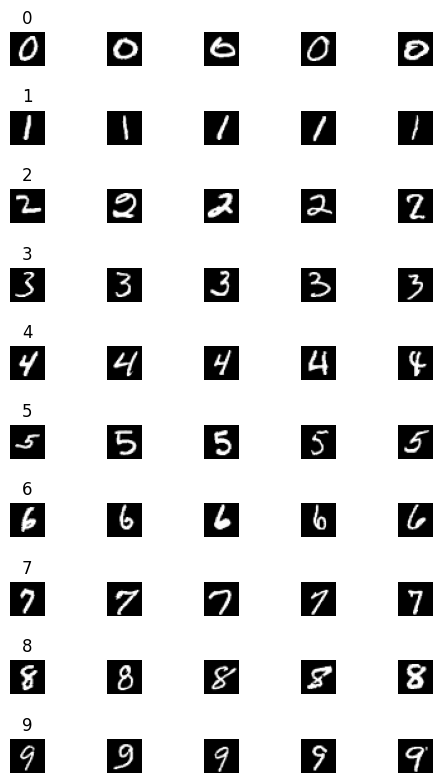

In [6]:
# Store the number of samples for each digit class
num_of_samples = []

# Display a grid of digit images: 10 rows (classes) x 5 columns (samples)
cols = 5
num_classes = 10

fig, axs = plt.subplots(nrows=num_classes, ncols=cols, figsize=(5, 8))
fig.tight_layout()

for i in range(cols):               # For each column
    for j in range(num_classes):   # For each digit class (0–9)

        # Select all images that belong to class j
        x_selected = X_train[y_train == j]

        # Display a random image from that class
        random_index = random.randint(0, len(x_selected) - 1)
        axs[j][i].imshow(x_selected[random_index], cmap="gray")

        # Remove axis labels for cleaner view
        axs[j][i].axis("off")

        # On the first column, show the digit label and count samples
        if i == 0:
            axs[j][i].set_title(str(j))
            num_of_samples.append(len(x_selected))


[5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


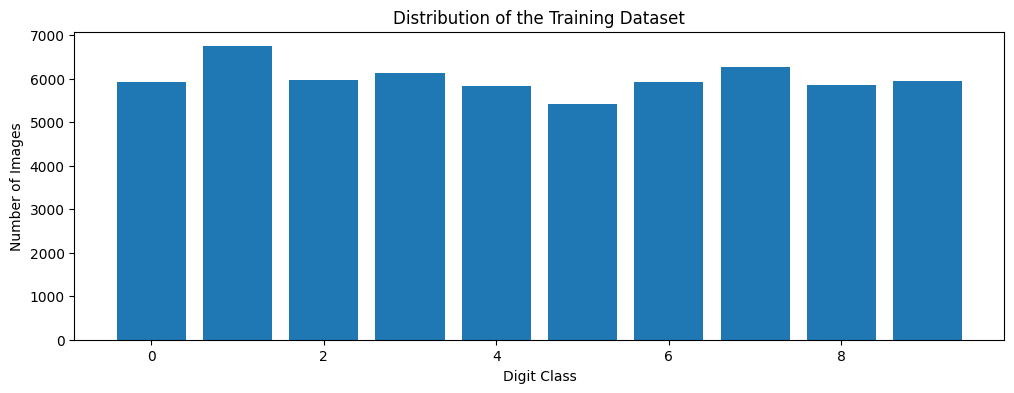

In [7]:
# Print the number of images for each digit class (0–9)
print(num_of_samples)

# Plot the class distribution
plt.figure(figsize=(12, 4))
plt.bar(range(num_classes), num_of_samples)

plt.title("Distribution of the Training Dataset")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")

plt.show()


In [8]:
# Convert labels to one-hot encoded vectors (10 classes: 0–9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalize pixel values from the range [0, 255] to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten each 28x28 image into a 784-dimensional vector
num_pixels = 28 * 28  # 784

X_train = X_train.reshape(X_train.shape[0], num_pixels)
X_test = X_test.reshape(X_test.shape[0], num_pixels)

print("X_train shape:", X_train.shape)  # (60000, 784)
print("X_test shape:", X_test.shape)    # (10000, 784)


X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [9]:
def create_model():
    model = Sequential()

    # Input layer: 784 inputs (flattened 28x28 image)
    model.add(Dense(10, input_dim=num_pixels, activation='relu'))

    # Hidden layers
    model.add(Dense(30, activation='relu'))
    model.add(Dense(10, activation='relu'))

    # Output layer: 10 classes (digits 0–9)
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [10]:
# Note: A simple fully-connected (linear) neural network does not scale well
# for complex image tasks. CNNs are usually preferred for image processing.

model = create_model()

# Display the model structure and parameter count
print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,600 (33.59 KB)

 Trainable params: 8,600 (33.59 KB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7143 - loss: 0.8486 - val_accuracy: 0.9147 - val_loss: 0.2938
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8966 - loss: 0.3367 - val_accuracy: 0.9198 - val_loss: 0.2715
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9076 - loss: 0.3101 - val_accuracy: 0.9287 - val_loss: 0.2438
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9142 - loss: 0.2859 - val_accuracy: 0.9310 - val_loss: 0.2399
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9174 - loss: 0.2764 - val_accuracy: 0.9322 - val_loss: 0.2281
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9161 - loss: 0.2747 - val_accuracy: 0.9337 - val_loss: 0.2328
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9204 - loss: 0.2655 - val_accuracy: 0.9355 - val_loss: 0.2265
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9203 - loss: 0.2603 - val_accuracy: 0.

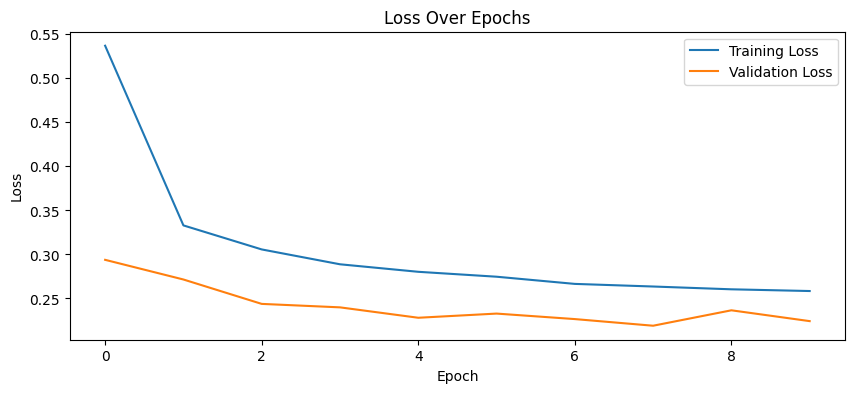

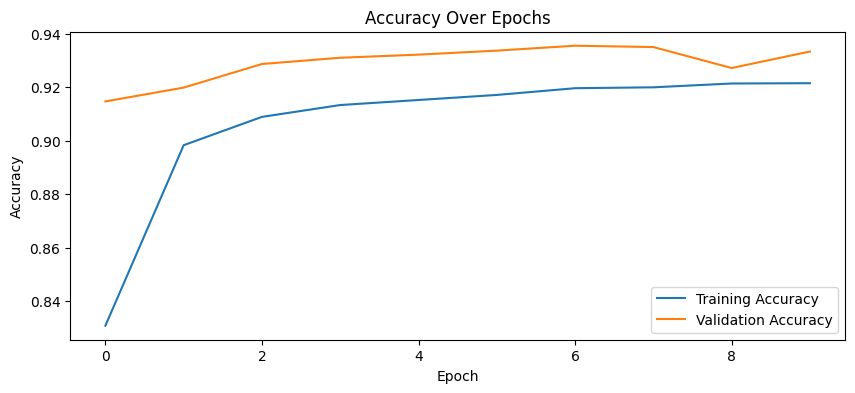

Test Loss: 0.2661832273006439
Test Accuracy: 0.9229999780654907


In [11]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,   # 10% of data used for validation
    epochs=10,              # Train for 10 passes over the data
    batch_size=200,         # Update weights after every 200 samples
    verbose=1,
    shuffle=True
)

# ----- Plot Loss -----
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training Loss', 'Validation Loss'])
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# ----- Plot Accuracy -----
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# ----- Evaluate the Model -----
score = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicted digit: 2


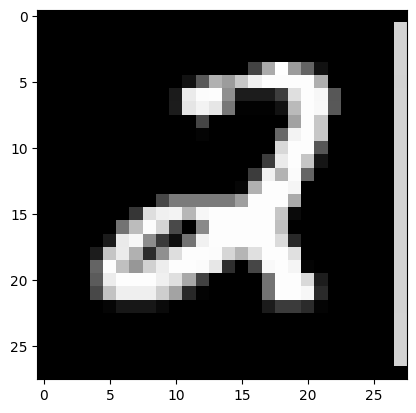

In [19]:
import requests
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

url = 'https://colah.github.io/posts/2014-10-Visualizing-MNIST/img/mnist_pca/MNIST-p1815-4.png'
response = requests.get(url, stream=True)
img = Image.open(response.raw)
plt.imshow(img, cmap='gray')

img = np.asarray(img)
img = cv2.resize(img, (28, 28))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.bitwise_not(img)

plt.imshow(img, cmap='gray')

# normalization
img = img / 255.0

# reshape for model
img = img.reshape(1, 784)

# modern prediction
prediction = np.argmax(model.predict(img), axis=1)
print("Predicted digit:", prediction[0])